# Wavelet clusters — uniform subsample, one normalisation (paw, left paw, wheel, left paw + wheel)

Copy of `3.3_wavelet_clusters.ipynb`, fed by `3.2_wavelet_subsample_uniform.ipynb`. The
original is left untouched, and so are its output folders.

**Pipeline:** `log(x + EPS)` (if `LOG`) → one standardisation (`NORM`) → PCA to `CUTOFF`
variance → k-means (`K`) → nearest centroid for every frame of every session. **The training
frames and the labelled frames go through the same function with the same statistics**,
which the original did not do: it z-scored the training frames by their biased subsample's
stats and the labelled frames by full-session stats, and ~10% of frames changed label
because of it.

**Which sessions define the states, and which get labelled** — `FIT_SETS`, `LABEL_SETS`.
A *set* is `(dataset, stage)`: a dataset as in `3.2_wavelet_subsample_uniform.ipynb` (whose
output this reads), optionally restricted to one training stage, a subfolder of
`data/design_matrices/1_camera_setup/` (`session_1`, `last_training`, `biased`, ...).
- One set fitted and labelled (the default) is the usual single-dataset clustering.
- Several sets give ONE state space for all of them, e.g. every training stage plus proficient,
  so that states mean the same thing at every stage. With `BALANCE = 'set'` every set contributes
  the same number of frames, so the stage with the most sessions does not define the space.
  Within a set, every session contributes its 2,000 frames, as always.
- `FIT_NAME` is appended to the states folder (`..._fit-<name>/`), so fits with different
  reference sets never overwrite each other. It is required as soon as more than one set is
  fitted.

`VAR = 'left_paw_wheel'` replaces `3.3_left_paw_wheel_clusters.ipynb`.

**`NORM`** — one value for every feature, or one per SOURCE, e.g.
`{'left_paw': 'session', 'wheel': 'global'}`. The wheel is camera-free and its level carries
little lab signal (`vigor/zscore/README.md`), so it can keep its level while the paw is
z-scored per session.
- `'session'`: each session is z-scored by its **own full-session** mean and SD. This removes
  each session's overall amplitude level (camera distance, pixel scale, and also real vigour)
  by construction, as the original did.
- `'global'`: one mean and SD for everybody, from the pooled training set. This only puts the
  features on a common scale; **between-session level differences, rig included, stay in.**

The original's second and third z-scores (per-session on the subsample, then pooled, then
`global_mean`/`global_std` at labelling) were exact no-ops once sessions were already mean 0 /
SD 1, so there is one standardisation here.

**Bugs fixed from the original**
- The elbow plot fitted k-means on PCs 0–1 only; it now uses all retained PCs (k is still
  fixed by `K`; the elbow is only a diagnostic).
- The example t-SNE labelled frames with `(x - global_mean) / global_std`, skipping the
  session z-score, so its colours were not the saved states. It now uses `label_session`.
- The per-session plot measured distances to the centroids without PCA. It now uses
  `label_session`, and draws only `N_PLOT_SESSIONS` sessions instead of all of them.
- `sessions_to_exclude` held eids but was compared against `(mouse, eid)` tuples, so **nothing
  was ever excluded**. The list is kept as `EXCLUDE`; `APPLY_EXCLUDE = False` reproduces the
  original behaviour.
- The chained assignment `design_matrix[state_name][not_nan] = ...` is gone (it was not used).

**The configuration the paper uses** is `LOG = False`, `NORM = 'session'`, the defaults below:
it writes `data/paw_states_uniform_raw_sessionz/`. (`vigor/zscore/` compares all four
combinations; see its README for why this one.)

**State numbering.** States are numbered by vigor (mean standardised power): state 0 is the
stillest, state K−1 the most vigorous. The notebook prints each state's vigor, left − right gap
and share. For paw with K = 8, no log and session z, colours come from `paper_style` after
`ps.use_paw_states('uniform')`, whose palette is derived for exactly these states; other
variants are drawn in viridis. How these states relate to the production ones is in
`vigor/zscore/README.md`. The hand-written `fix_mapping` tables of the original refer to its
own numbering and do not apply here.

In [1]:
"""SHARED DEFINITIONS -- identical in 3.2_..._uniform and 3.3_..._uniform."""
import os
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

DATA = '/home/ines/repositories/representation_learning_variability/paper-individuality/data/'

# each dataset keeps its wavelet folders under its own root
DATASETS = {'proficient': '', 'neuromodulators': 'neuromodulators/', 'training': 'training/'}

BANDS = ['0.5', '1.0', '2.0', '4.0', '8.0']     # the bands the clustering uses
# source -> (wavelet folders to try in order, file prefix, columns, log floor)
#   log floor: log(x + floor), only used with LOG = True. Paw amplitudes have a median of ~1-6
#   and a 1st percentile of ~0.01-0.07, so 0.1 compresses a still paw's tracking jitter. Wheel
#   amplitudes are ~20x smaller (still ~1e-4, moving ~0.05-0.3), so its floor is 0.005.
#   16 / 32 Hz are left out everywhere: for the wheel they are encoder noise.
SOURCES = {
    'paw':      (['paw_wavelets/'], 'paw_vel_wavelets_',
                 [f'{p}_{a}{b}' for p in ('l_paw', 'r_paw') for a in 'xy' for b in BANDS], 0.1),
    # the proficient dataset keeps the left paw inside the both-paw files
    'left_paw': (['left_paw_wavelets/', 'paw_wavelets/'], 'paw_vel_wavelets_',
                 [f'l_paw_{a}{b}' for a in 'xy' for b in BANDS], 0.1),
    'wheel':    (['wheel_wavelets/'], 'wheel_vel_wavelets_',
                 [f'avg_wheel_vel{b}' for b in BANDS], 0.005),
}
# what can be clustered: one source, or several merged on Bin
VARS = {'paw': ['paw'], 'left_paw': ['left_paw'], 'wheel': ['wheel'],
        'left_paw_wheel': ['left_paw', 'wheel']}


def features(var):
    return [c for s in VARS[var] for c in SOURCES[s][2]]


def feature_sources(var):
    """The source of every feature column, in features() order."""
    return [s for s in VARS[var] for _ in SOURCES[s][2]]


def feature_eps(var):
    return np.array([SOURCES[s][3] for s in feature_sources(var)])


def source_dir(dataset, src):
    root = DATA + DATASETS[dataset]
    for d in SOURCES[src][0]:
        if os.path.isdir(root + d):
            return root + d
    raise FileNotFoundError(f'no {SOURCES[src][0]} under {root}')


def session_tags(dataset, var):
    """'<eid>_<mouse>' of every session that has a file for EVERY source of `var`."""
    have = []
    for s in VARS[var]:
        d, prefix = source_dir(dataset, s), SOURCES[s][1]
        have.append({f[len(prefix):] for f in os.listdir(d) if f.startswith(prefix)})
    return sorted(set.intersection(*have))


def load_frame(dataset, var, tag, extra=()):
    """One session, its sources merged on Bin -> Bin, the features, and whichever `extra`
    columns (raw traces for plotting) the files have."""
    out = None
    for s in VARS[var]:
        path = source_dir(dataset, s) + SOURCES[s][1] + tag
        names = set(pq.read_schema(path).names)
        taken = set() if out is None else set(out.columns)
        cols = ['Bin'] + SOURCES[s][2] + [c for c in extra if c in names and c not in taken]
        df = pd.read_parquet(path, columns=cols)
        out = df if out is None else out.merge(df, on='Bin', how='inner')
    return out


def load_session(dataset, var, tag):
    """-> (raw amplitudes of the frames with every feature finite, their Bin, the mask)."""
    df = load_frame(dataset, var, tag)
    X = df[features(var)].to_numpy(float)
    valid = np.isfinite(X).all(axis=1)
    return X[valid], df['Bin'].to_numpy()[valid], valid


# TRAINING STAGES: each is a subfolder of design_matrices/1_camera_setup/ listing its sessions
STAGE_DIR = DATA + 'design_matrices/1_camera_setup/'


def stage_eids(stage):
    """The session eids of one training stage, e.g. 'session_1', 'last_training', 'biased'."""
    return {f.split('_')[2] for f in os.listdir(STAGE_DIR + stage) if 'design_matrix' in f}


def dataset_root(dataset, out_root=None):
    """Where a dataset's subsamples and states live: its own folder under DATA, or the same
    layout under `out_root` (test runs)."""
    return (out_root or DATA) + DATASETS[dataset]


In [3]:
"""IMPORTS AND KNOBS"""
import sys, pathlib, importlib
sys.path.insert(0, str(pathlib.Path(DATA).parent))
import paper_style as ps
importlib.reload(ps)
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from kneed import KneeLocator

# WHICH SESSIONS DEFINE THE STATES, AND WHICH GET LABELLED -- see above.
# A set is (dataset, stage): dataset in 'proficient' | 'neuromodulators' | 'training'; stage
# None, or a folder of data/design_matrices/1_camera_setup/ whose sessions it keeps.
FIT_SETS = {'neuromodulators': ('neuromodulators', None)}
# e.g. one state space for learning, every stage weighing the same:
FIT_SETS = {'Early': ('training', 'session_1'), 'Late': ('training', 'last_training'),
            'Pre-rec': ('training', 'biased'), 'Proficient': ('proficient', None)}
LABEL_SETS = FIT_SETS   # may differ, e.g. fit on some sets and label others too
BALANCE  = 'set'    # 'session': every session's 2,000 frames; 'set': ALSO the same number
                        #   of frames per fit set (the smallest set's total)
FIT_NAME = 'stages'         # None: no suffix (one fit set only); else '..._fit-<FIT_NAME>/'
VAR    = 'left_paw_wheel'          # 'paw' | 'left_paw' | 'wheel' | 'left_paw_wheel'
LOG    = False          # log(x + EPS) before standardising; EPS comes from 3.2's files
NORM   = 'session'      # 'session' | 'global', or per source -- see above
K      = 8            # the paper's paw states (paper_style.N_PAW_STATES)
CUTOFF = 0.95           # PCA variance kept
SEED   = 2024           # k-means seed, as in the original
N_INIT = 10             # k-means restarts, keep the best. sklearn >= 1.4 defaults to ONE, which
                        # lands in worse local optima: seed 2024 alone gave inertia 5.1167e6 and a
                        # symmetric moderate pair; with 10, every seed converges to 5.1128e6
                        # (vigor/zscore/results_why_states_changed_ninit.txt)
N_PLOT_SESSIONS = 10
SAVE_DISTANCES = True   # centroid_distances_* are ~95% of the output's size on disk
MAX_SESSIONS = None     # an int labels only the first n sessions, for a quick test
OUT_ROOT     = None     # None = DATA; a path redirects input AND output (tests), same layout

APPLY_EXCLUDE = False   # the original's list never took effect; True applies it
EXCLUDE = ['a8a8af78-16de-4841-ab07-fde4b5281a03', '8c33abef-3d3e-4d42-9f27-445e9def08f9',
           'ebe2efe3-e8a1-451a-8947-76ef42427cc9', '91bac580-76ed-41ab-ac07-89051f8d7f6e',
           '8a1cf4ef-06e3-4c72-9bc7-e1baa189841b', '64977c74-9c04-437a-9ea1-50386c4996db',
           '90e524a2-aa63-47ce-b5b8-1b1941a1223a', '30af8629-7b96-45b7-8778-374720ddbc5e',
           'f3eeb2d4-87ce-49ae-8a74-21665f6f1536', 'fcd49e34-f07b-441c-b2ac-cb8c462ec5ac']

FEATS = features(VAR)
SRC = np.array(feature_sources(VAR))
COL_NORM = np.array([NORM if isinstance(NORM, str) else NORM[x] for x in SRC])
assert set(COL_NORM) <= {'session', 'global'}, COL_NORM
_norm_tag = NORM if isinstance(NORM, str) else '_'.join(f'{x}-{NORM[x]}' for x in VARS[VAR])

if len(FIT_SETS) > 1 or set(LABEL_SETS) != set(FIT_SETS):
    assert FIT_NAME, 'name the fit (FIT_NAME) when it is not one set fitted and labelled'
for _n, (_ds, _st) in {**FIT_SETS, **LABEL_SETS}.items():
    assert _ds in DATASETS and (_st is None or os.path.isdir(STAGE_DIR + _st)), (_n, _ds, _st)

_states_name = (f'{VAR}_states_uniform_{"log" if LOG else "raw"}_{_norm_tag}z'
                + (f'_fit-{FIT_NAME}' if FIT_NAME else '') + '/')
STATES_DIRS = {ds: dataset_root(ds, OUT_ROOT) + _states_name for ds, _ in LABEL_SETS.values()}
for d in STATES_DIRS.values():
    os.makedirs(d, exist_ok=True)
_norm_print = {x: str(COL_NORM[SRC == x][0]) for x in VARS[VAR]}
print(f'{VAR}; NORM per feature source: {_norm_print}; balance: {BALANCE}')
print('fit on   ', FIT_SETS)
print('label    ', LABEL_SETS)
print('states ->', sorted(set(STATES_DIRS.values())))


left_paw_wheel; NORM per feature source: {'left_paw': 'session', 'wheel': 'session'}; balance: set
fit on    {'Early': ('training', 'session_1'), 'Late': ('training', 'last_training'), 'Pre-rec': ('training', 'biased'), 'Proficient': ('proficient', None)}
label     {'Early': ('training', 'session_1'), 'Late': ('training', 'last_training'), 'Pre-rec': ('training', 'biased'), 'Proficient': ('proficient', None)}
states -> ['/home/ines/repositories/representation_learning_variability/paper-individuality/data/left_paw_wheel_states_uniform_raw_sessionz_fit-stages/', '/home/ines/repositories/representation_learning_variability/paper-individuality/data/training/left_paw_wheel_states_uniform_raw_sessionz_fit-stages/']


In [4]:
"""LOAD THE SUBSAMPLES OF EVERY SET"""
def set_tags(name):
    """The sessions of one set that 3.2 subsampled (stage filter, exclusions, MAX_SESSIONS)."""
    ds, stage = ALL_SETS[name]
    d = dataset_root(ds, OUT_ROOT) + f'{VAR}_subsampled_wavelets_uniform/'
    tags = sorted(t[:-4] for t in os.listdir(d) if t.endswith('.npz'))
    if stage:
        keep = stage_eids(stage)
        tags = [t for t in tags if t[:36] in keep]
    if APPLY_EXCLUDE:
        tags = [t for t in tags if t[:36] not in EXCLUDE]
    return tags[:MAX_SESSIONS]


ALL_SETS = {**FIT_SETS, **LABEL_SETS}
SET_TAGS = {n: set_tags(n) for n in ALL_SETS}
# read every file ONCE into plain arrays (an NpzFile re-reads the whole array on every ['key'])
subs = {}
for n in ALL_SETS:
    for t in SET_TAGS[n]:
        with np.load(dataset_root(ALL_SETS[n][0], OUT_ROOT) + f'{VAR}_subsampled_wavelets_uniform/{t}.npz') as z:
            subs[(n, t)] = {k: z[k] for k in z.files}
assert all(list(z['features']) == FEATS for z in subs.values())
# the log floor per feature (older files store one number for all)
EPS = np.broadcast_to(np.asarray(next(iter(subs.values()))['eps'], float), (len(FEATS),)).copy()
assert all(np.allclose(np.broadcast_to(z['eps'], EPS.shape), EPS) for z in subs.values())
print({n: len(t) for n, t in SET_TAGS.items()}, 'sessions;',
      'log floor per source:', {str(x): float(e) for x, e in zip(SRC, EPS)})


def amp(raw):
    """The amplitude scale the clustering works in."""
    return np.log(raw + EPS) if LOG else raw


def session_stats(raw):
    """Full-session mean and SD in the working scale (ddof=0, as scipy.stats.zscore)."""
    x = amp(raw)
    return x.mean(0), x.std(0)


# THE TRAINING FRAMES: every fit set's subsamples; with BALANCE = 'set', the same number of
# frames from each set (a random draw, without replacement, from the larger ones)
_rng = np.random.default_rng(SEED)
_rows = {n: np.concatenate([np.c_[np.full(len(subs[(n, t)]['sub']), i), np.arange(len(subs[(n, t)]['sub']))]
                            for i, t in enumerate(SET_TAGS[n])]) for n in FIT_SETS}
if BALANCE == 'set':
    _m = min(len(r) for r in _rows.values())
    _rows = {n: r[np.sort(_rng.choice(len(r), _m, replace=False))] for n, r in _rows.items()}
elif BALANCE != 'session':
    raise ValueError(f"BALANCE must be 'session' or 'set', got {BALANCE!r}")
TRAIN_ROWS = [(n, SET_TAGS[n][i], j) for n, r in _rows.items() for i, j in r]   # (set, tag, row)

# 'global': ONE mean/SD from the training frames (every session, and with BALANCE='set' every
# set, weighing as in the fit)
_blocks = pd.DataFrame(TRAIN_ROWS, columns=['set', 'tag', 'row'])
_pool = np.vstack([amp(subs[(n, t)]['sub'][g['row'].to_numpy()])
                   for (n, t), g in _blocks.groupby(['set', 'tag'], sort=False)])
POOLED = (_pool.mean(0), _pool.std(0))
_G = COL_NORM == 'global'


def mix(sess):
    """Per feature: the session's own stats where NORM is 'session', the pooled ones where
    it is 'global'."""
    return np.where(_G, POOLED[0], sess[0]), np.where(_G, POOLED[1], sess[1])


def stats_for(key):
    """The stats 3.2 saved for session key = (set, tag) (computed over ALL its frames), mixed per NORM."""
    z = subs[key]
    return mix((z['mean_log'], z['sd_log']) if LOG else (z['mean_raw'], z['sd_raw']))


def standardise(raw, stats):
    mean, sd = stats
    return (amp(raw) - mean) / sd


# standardise per session (vectorised: one block per session, rows in TRAIN_ROWS order)
X_train = np.vstack([standardise(subs[(n, t)]['sub'][g['row'].to_numpy()], stats_for((n, t)))
                     for (n, t), g in _blocks.groupby(['set', 'tag'], sort=False)])
TRAIN_SET = np.concatenate([np.full(len(g), n) for (n, t), g in _blocks.groupby(['set', 'tag'], sort=False)])
print('training set', X_train.shape, '-- frames per fit set:',
      {n: int((TRAIN_SET == n).sum()) for n in FIT_SETS})

{'Early': 49, 'Late': 55, 'Pre-rec': 116, 'Proficient': 332} sessions; log floor per source: {'left_paw': 0.1, 'wheel': 0.005}
training set (392000, 15) -- frames per fit set: {'Early': 98000, 'Late': 98000, 'Pre-rec': 98000, 'Proficient': 98000}


## PCA

11 PCs keep 95.6% of the variance


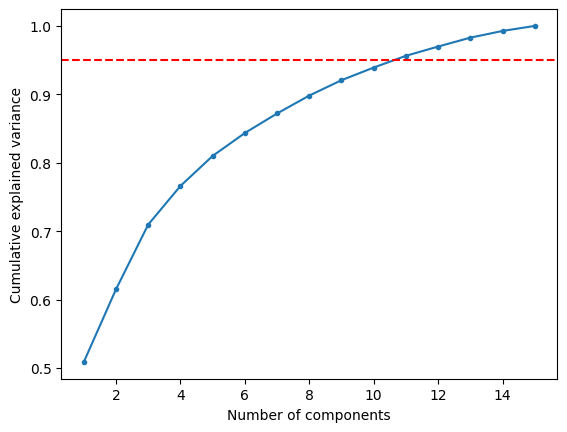

In [6]:
pca = PCA(n_components=len(FEATS)).fit(X_train)
cumvar = np.cumsum(pca.explained_variance_ratio_)
N_PC = int(np.searchsorted(cumvar, CUTOFF) + 1)
if VAR == 'wheel':
    N_PC = len(FEATS)
P_train = pca.transform(X_train)[:, :N_PC]
print(f'{N_PC} PCs keep {cumvar[N_PC - 1]:.1%} of the variance')

plt.plot(np.arange(1, len(cumvar) + 1), cumvar, 'o-', ms=3)
plt.axhline(CUTOFF, color='r', ls='--')
plt.xlabel('Number of components'); plt.ylabel('Cumulative explained variance')
plt.show()

## Elbow (diagnostic only — `K` is set above)
Fixed: fitted on all retained PCs, not just the first two. A random 100,000 training frames
keep the 25 fits quick; the inertia curve is smooth enough that this does not move the knee.

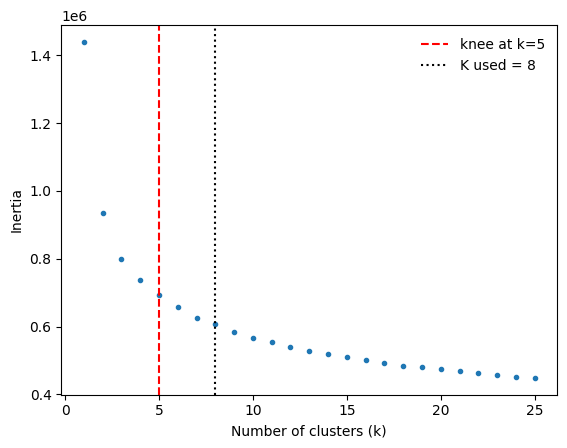

In [7]:
_rows = np.random.default_rng(0).choice(len(P_train), min(100_000, len(P_train)), replace=False)
Ks = range(1, 26)
inertia = [KMeans(n_clusters=k, random_state=42).fit(P_train[_rows]).inertia_ for k in Ks]
knee = KneeLocator(list(Ks), inertia, curve='convex', direction='decreasing').knee
plt.plot(list(Ks), inertia, 'o', ms=3)
plt.axvline(knee, color='r', ls='--', label=f'knee at k={knee}')
plt.axvline(K, color='k', ls=':', label=f'K used = {K}')
plt.xlabel('Number of clusters (k)'); plt.ylabel('Inertia'); plt.legend(frameon=False)
plt.show()

## k-means, numbered stillest → most vigorous

In [8]:
km = KMeans(n_clusters=K, random_state=SEED, n_init=N_INIT).fit(P_train)
print(f'k-means inertia {km.inertia_:.5e} (best of {N_INIT})')
_power = np.array([X_train[km.labels_ == c].mean() for c in range(K)])
ORDER = np.argsort(_power)                 # new state s = old cluster ORDER[s]
CENTROIDS = km.cluster_centers_[ORDER]
train_states = np.argsort(ORDER)[km.labels_]

# what each state is: vigor = mean standardised power over all features; per source when
# there are several; for both paws, the left-right gap that paper_style's palette encodes
_tab = {'vigor': [X_train[train_states == s].mean() for s in range(K)]}
if len(VARS[VAR]) > 1:
    for x in VARS[VAR]:
        _tab[f'{x} power'] = [X_train[train_states == s][:, SRC == x].mean() for s in range(K)]
if VAR == 'paw':
    _tab['L-R gap'] = [X_train[train_states == s][:, :10].mean() - X_train[train_states == s][:, 10:].mean()
                       for s in range(K)]                 # l_paw columns first, then r_paw
_tab['share'] = np.bincount(train_states, minlength=K) / len(train_states)
STATE_TABLE = pd.DataFrame(_tab)
STATE_TABLE.index.name = 'state'
display(STATE_TABLE.round(3))

print('training occupancy by state:', np.round(np.bincount(train_states, minlength=K) / len(train_states), 3))

k-means inertia 2.38123e+06 (best of 10)


,vigor,left_paw power,wheel power,share
state,,,,
0,-0.540,-0.534,-0.554,0.424
1,-0.130,-0.124,-0.142,0.240
2,0.256,0.043,0.683,0.117
3,0.663,0.749,0.490,0.077
4,0.785,1.005,0.345,0.068
5,1.307,1.004,1.914,0.043
6,2.052,2.284,1.588,0.022
7,2.607,3.406,1.009,0.009


training occupancy by state: [0.424 0.24  0.117 0.077 0.068 0.043 0.022 0.009]


## Label every frame of every session

In [9]:
def full_stats(raw):
    """The standardisation for a session's frames: its own full-session stats, mixed per NORM."""
    return mix(session_stats(raw))


def label_session(key):
    """Every valid frame of session key = (set, tag) -> (states, centroid distances, Bin,
    valid mask, raw). The same standardise() the training frames went through, with stats
    recomputed from the full session and checked against the ones 3.2 saved."""
    name, tag = key
    raw, bins, valid = load_session(ALL_SETS[name][0], VAR, tag)
    stats = full_stats(raw)
    assert np.allclose(stats[0], stats_for(key)[0]) and np.allclose(stats[1], stats_for(key)[1])
    P = pca.transform(standardise(raw, stats))[:, :N_PC]
    D = cdist(P, CENTROIDS)
    return D.argmin(1), D, bins, valid, raw


LABEL_KEYS = [(n, t) for n in LABEL_SETS for t in SET_TAGS[n]]
occupancy = {}
for key in LABEL_KEYS:
    states, D, bins, _, _ = label_session(key)
    out = STATES_DIRS[ALL_SETS[key[0]][0]]
    session, mouse = key[1][:36], key[1][37:]
    # same file names and layout as the original, so 4.0 / 5_syllable_generation can point here
    np.save(out + f'most_likely_states_{K}_{mouse}{session}', np.array([states, bins]))
    if SAVE_DISTANCES:
        np.save(out + f'centroid_distances_{K}_{mouse}{session}', D)
    occupancy[key] = np.bincount(states, minlength=K) / len(states)
occupancy = pd.DataFrame(occupancy, index=[f'state{s}' for s in range(K)]).T
occupancy.index.names = ['set', 'session']
print(f'labelled {len(occupancy)} sessions')
occupancy.groupby(level='set', sort=False).mean().round(3)

labelled 552 sessions


,state0,state1,state2,state3,state4,state5,state6,state7
set,,,,,,,,
Early,0.504,0.216,0.088,0.071,0.042,0.039,0.027,0.012
Late,0.359,0.264,0.146,0.077,0.088,0.041,0.017,0.007
Pre-rec,0.392,0.251,0.134,0.075,0.077,0.043,0.019,0.009
Proficient,0.435,0.231,0.102,0.083,0.066,0.051,0.024,0.009


## What the states are

violet = left-paw-led, teal = wheel-led, dark = vigorous


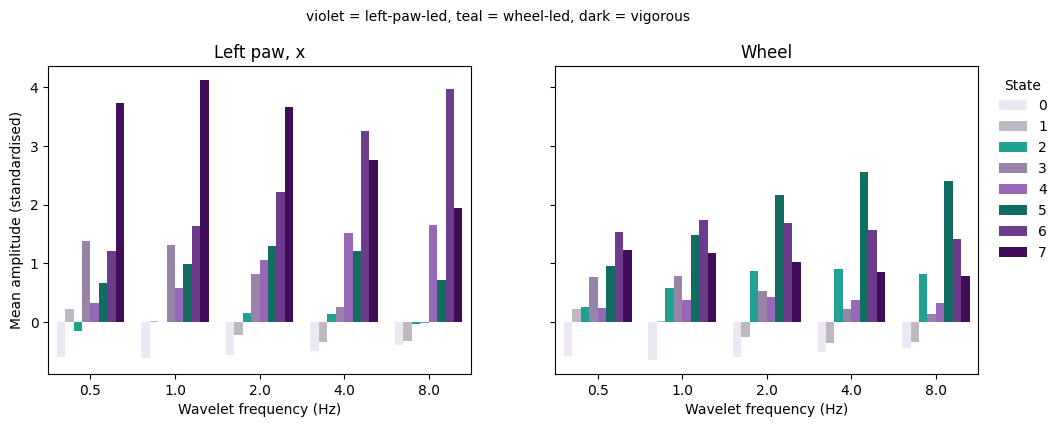

In [10]:
prof = pd.DataFrame(X_train, columns=FEATS).assign(state=train_states)
prof = prof.melt(id_vars='state')
# COLOURS BY THE PAPER'S RULE (paper_style.state_palette): lightness = vigor rank, hue = what
# the state leans to, chroma = how far. Proficient both-paw states use the paper's own palette.
if (FIT_SETS == {'proficient': ('proficient', None)} and not FIT_NAME and VAR == 'paw'
        and K == ps.N_PAW_STATES and not LOG and NORM == 'session'):
    ps.use_paw_states('uniform')                  # the palette derived for exactly these states
    palette = list(ps.PAW_STATE_COLORS)
    COLOUR_KEY = 'violet = left paw, amber = right paw, dark = vigorous'
else:
    _src_power = lambda x: np.array([X_train[train_states == s][:, SRC == x].mean() for s in range(K)])  # noqa: E731
    if VAR == 'paw':
        _gap, _hues = STATE_TABLE['L-R gap'].to_numpy(), (310, 90)
        COLOUR_KEY = 'violet = left paw, amber = right paw, dark = vigorous'
    elif VAR == 'left_paw_wheel':
        _gap, _hues = _src_power('left_paw') - _src_power('wheel'), (310, ps.WHEEL_HUE)
        COLOUR_KEY = 'violet = left-paw-led, teal = wheel-led, dark = vigorous'
    else:                                         # one signal: lightness only, in its own hue
        _gap, _hues = None, ((310,) if VAR == 'left_paw' else (ps.WHEEL_HUE,))
        COLOUR_KEY = 'dark = vigorous'
    palette = ps.state_palette(STATE_TABLE['vigor'].to_numpy(), _gap, _hues)
    STATE_TABLE['gap'] = np.nan if _gap is None else _gap
STATE_TABLE['colour'] = palette
for _d in set(STATES_DIRS.values()):                   # so downstream figures use the same
    STATE_TABLE.to_csv(_d + 'state_palette.csv')
print(COLOUR_KEY)
HUE_ORDER = list(range(K))                      # states are numbered by vigor

# one panel per signal, the x axis's bands (and the wheel's)
PANELS = {'paw': [('l_paw_x', 'Left paw, x'), ('r_paw_x', 'Right paw, x')],
          'left_paw': [('l_paw_x', 'Left paw, x')],
          'wheel': [('avg_wheel_vel', 'Wheel')]}
panels = [p for x in VARS[VAR] for p in PANELS[x]]
fig, axes = plt.subplots(1, len(panels), figsize=(6 * len(panels), 4), sharey=True, squeeze=False)
for ax, (pre, name) in zip(axes[0], panels):
    cols = [f'{pre}{b}' for b in BANDS]
    sns.barplot(data=prof[prof['variable'].isin(cols)], x='variable', y='value', hue='state',
                hue_order=HUE_ORDER, palette={k: palette[k] for k in range(K)},
                ax=ax, errorbar=None)
    ax.set_xticks(range(len(BANDS)), BANDS)
    ax.set_xlabel('Wavelet frequency (Hz)'); ax.set_title(name)
    ax.legend_.remove()
axes[0][0].set_ylabel(f'Mean {"log " if LOG else ""}amplitude (standardised)')
axes[0][-1].legend(title='State', loc='upper left', bbox_to_anchor=(1.02, 1), frameon=False)
fig.suptitle(COLOUR_KEY, y=1.02, fontsize=plt.rcParams['font.size'])
plt.show()

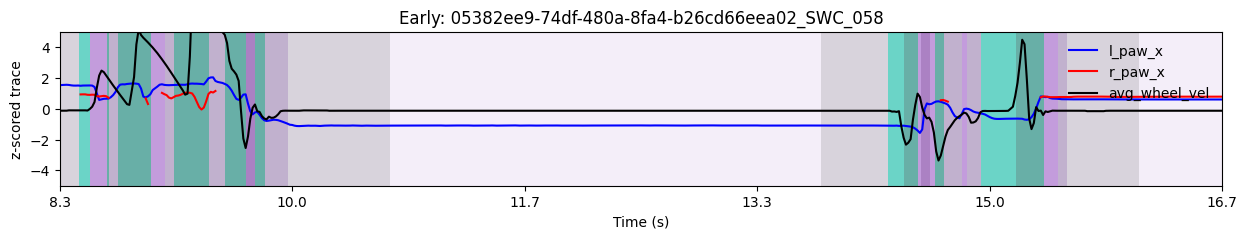

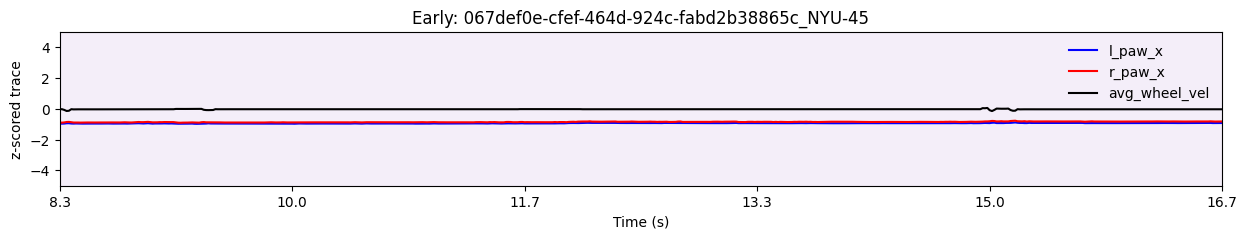

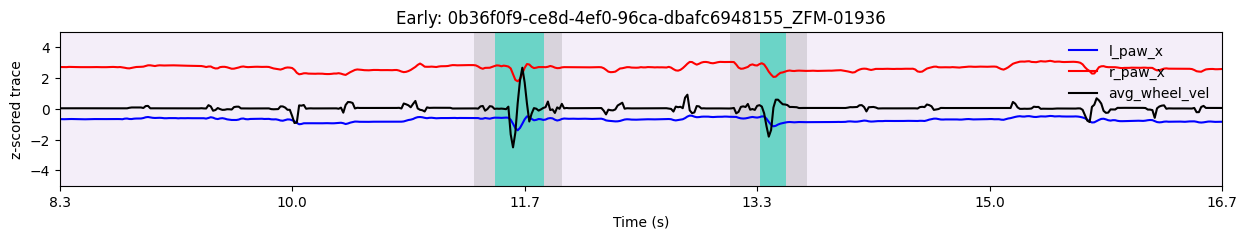

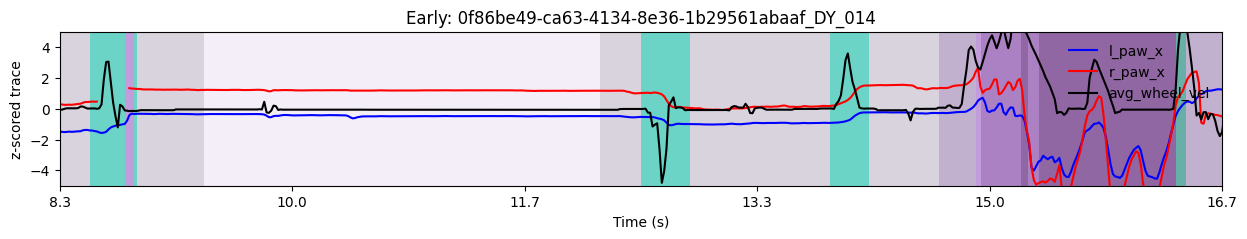

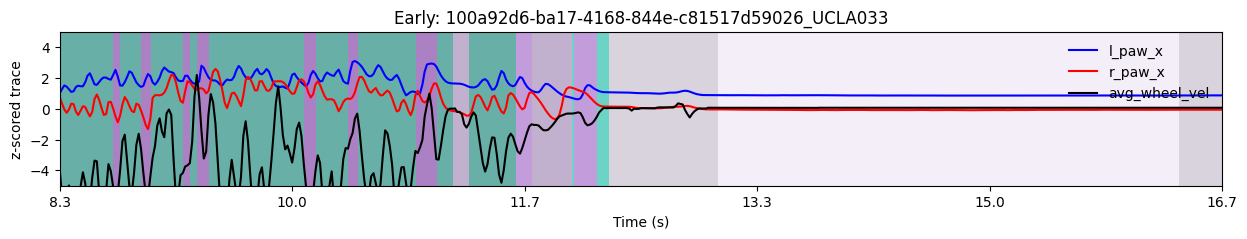

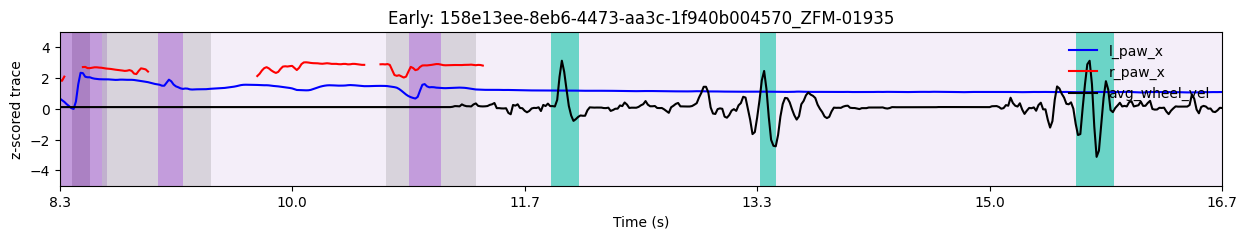

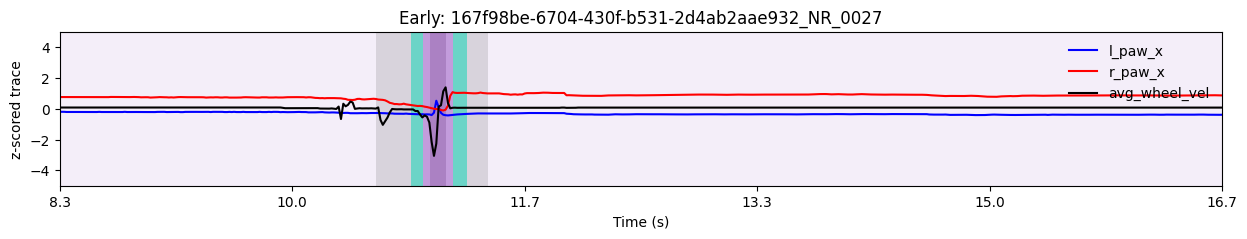

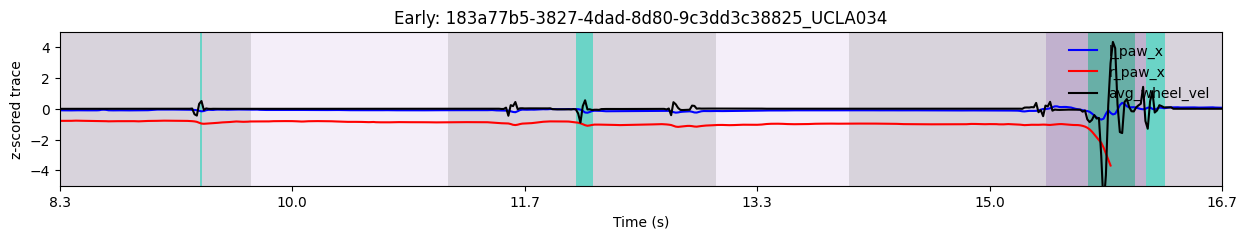

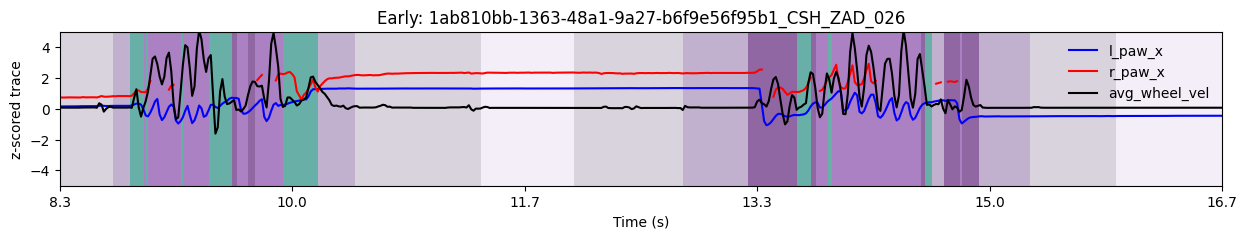

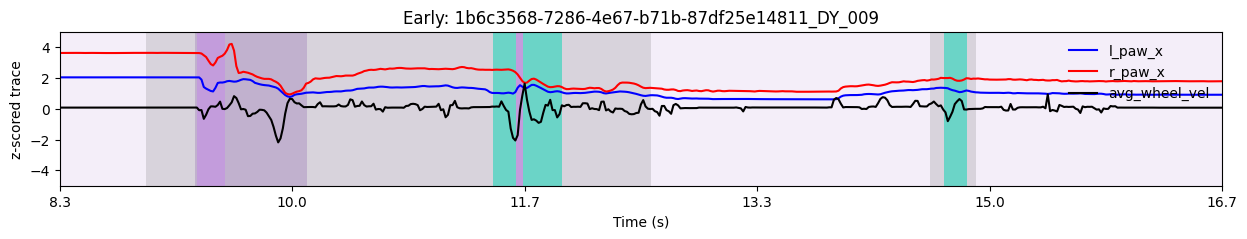

In [11]:
"""Example sessions: states under the paw traces. Fixed: uses label_session."""
from matplotlib.colors import ListedColormap
cmap = ListedColormap(palette)
for key in LABEL_KEYS[:N_PLOT_SESSIONS]:
    states, _, bins, valid, _ = label_session(key)
    dm = load_frame(ALL_SETS[key[0]][0], VAR, key[1], extra=('l_paw_x', 'r_paw_x', 'avg_wheel_vel'))
    dm = dm[valid].reset_index(drop=True)
    init, inter, fr = 500, 500, 60
    fig, ax = plt.subplots(figsize=(15, 2))
    ax.imshow(states[None, :], extent=(0, len(states), -10, 10), aspect='auto', alpha=0.6,
              cmap=cmap, vmin=-0.5, vmax=K - 0.5, interpolation='nearest')
    for c, col in [('l_paw_x', 'blue'), ('r_paw_x', 'red'), ('avg_wheel_vel', 'black')]:
        if c in dm:
            v = dm[c].to_numpy()
            ax.plot((v - np.nanmean(v)) / np.nanstd(v), color=col, label=c)
    ax.set_xlim(init, init + inter); ax.set_ylim(-5, 5)
    ax.set_xticks(np.arange(init, init + inter + 1, inter / 5),
                  np.round(np.arange(init, init + inter + 1, inter / 5) / fr, 1))
    ax.set_xlabel('Time (s)'); ax.set_ylabel('z-scored trace')
    ax.set_title(f'{key[0]}: {key[1]}'); ax.legend(frameon=False, loc='upper right')
    plt.show()

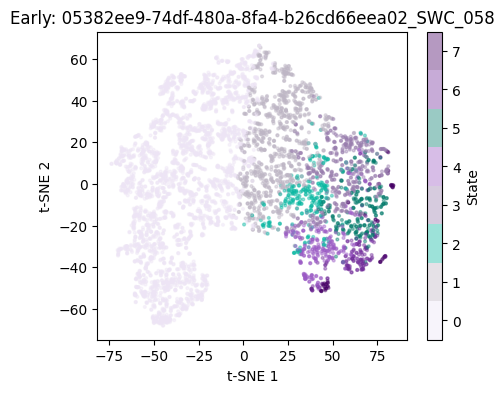

In [12]:
"""t-SNE of one example session, coloured by the SAVED states. Fixed: uses label_session."""
from sklearn.manifold import TSNE
key = LABEL_KEYS[0]
states, _, _, _, raw = label_session(key)
stats = full_stats(raw)
P = pca.transform(standardise(raw, stats))[:, :N_PC]
pick = np.random.default_rng(0).choice(len(P), min(5000, len(P)), replace=False)
emb = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(P[pick])
plt.figure(figsize=(5, 4))
sc = plt.scatter(*emb.T, c=states[pick], cmap=cmap, vmin=-0.5, vmax=K - 0.5, s=4, alpha=0.4)
plt.colorbar(sc, label='State', ticks=range(K))
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2'); plt.title(f'{key[0]}: {key[1]}')
plt.show()